In [1]:
import keras
from keras import layers
import tensorflow as tf
import matplotlib.pyplot as plt

2026-04-29 12:34:30.951640: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
# 1. Load data

In [5]:
IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32

In [6]:
train_ds = keras.utils.image_dataset_from_directory(
    'data/rps',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    subset="training",
    validation_split=0.2, # 20% validation images 
    seed=42
)

Found 2520 files belonging to 3 classes.
Using 2016 files for training.


In [7]:
val_ds = keras.utils.image_dataset_from_directory(
    'data/rps',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    subset="validation",
    validation_split=0.2, # 20% validation images 
    seed=42
)

Found 2520 files belonging to 3 classes.
Using 504 files for validation.


In [8]:
test_ds = keras.utils.image_dataset_from_directory(
    'data/rps-test-set',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

Found 372 files belonging to 3 classes.


In [9]:
class_names = train_ds.class_names

In [ ]:
class_names  # ['paper', 'rock', 'scissors'], paper=0, rock=1, scissors=2

['paper', 'rock', 'scissors']

In [ ]:
num_classes = len(train_ds.class_names) # 3

In [12]:
# 2. optimize input pipeline

In [16]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

In [17]:
# 3. Data augmentation

In [19]:
data_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2)
])

In [20]:
# 4. build CNN from scratch 

In [21]:
model = keras.Sequential([
    layers.Input(shape=(150, 150, 3)),
    data_aug,
    layers.Rescaling(1.0/255),

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

In [22]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [24]:
# model.summary()

In [25]:
history = model.fit(
    train_ds, 
    validation_data=val_ds,
    epochs=50,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    ]
)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 35s 501ms/step - accuracy: 0.4018 - loss: 1.0762 - val_accuracy: 0.4147 - val_loss: 0.9990
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 513ms/step - accuracy: 0.6979 - loss: 0.6823 - val_accuracy: 0.8909 - val_loss: 0.4606
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 510ms/step - accuracy: 0.8279 - loss: 0.4421 - val_accuracy: 0.9405 - val_loss: 0.1861
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 33s 524ms/step - accuracy: 0.9048 - loss: 0.2571 - val_accuracy: 0.8770 - val_loss: 0.2956
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 542ms/step - accuracy: 0.9291 - loss: 0.1796 - val_accuracy: 0.9940 - val_loss: 0.0407
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 539ms/step - accuracy: 0.9568 - loss: 0.1233 - val_accuracy: 0.9861 - val_loss: 0.0404
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 510ms/step - accuracy: 0.9539 - loss: 0.1139 - val_accuracy: 0.9960 - val_loss: 0.0158
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 565ms/step - accuracy: 0.9712 - loss: 0.0922 - val_accu

In [26]:
test_loss, test_acc = model.evaluate(test_ds)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step - accuracy: 0.9597 - loss: 0.1186


In [27]:
test_acc

0.9596773982048035

In [28]:
acc = history.history["accuracy"] # training accuracy 
val_acc = history.history["val_accuracy"] # testing accuracy 
loss = history.history["loss"] # training loss
val_loss = history.history["val_loss"] # testing loss

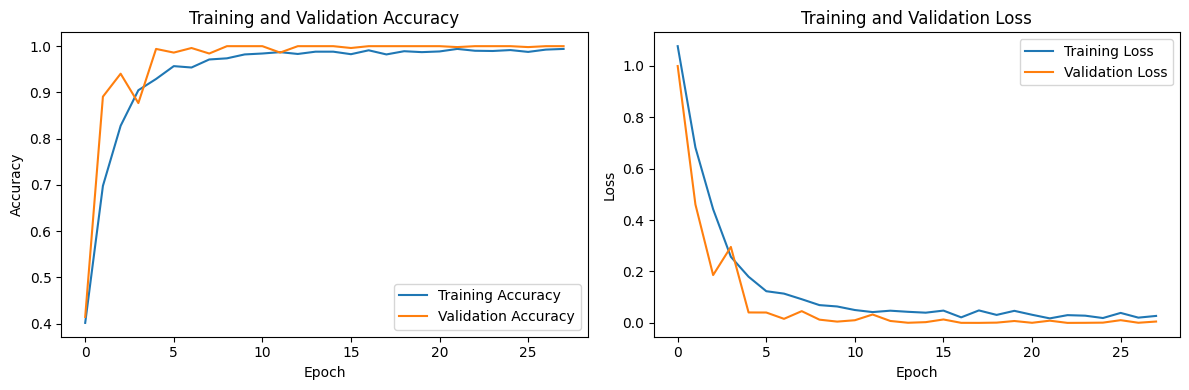

In [29]:
# Training Curves     
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))                                                                                     
plt.subplot(1, 2, 1)                                                                
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

In [30]:
model.save("rps_cnn.keras")

In [ ]:
# Single Image Classification                                                            
import numpy as np                                                                       

img_path = "paper01-000.png"                                  
                                                                                      
img = keras.utils.load_img(img_path, target_size=(150, 150))                             
img_array = keras.utils.img_to_array(img)                                                
img_array = tf.expand_dims(img_array, 0)  # add batch dim                                                                                                                       │
predictions = model.predict(img_array)                                                   
predicted_class = class_names[np.argmax(predictions[0])]                                  
confidence = 100 * np.max(predictions[0])  